
#  Imam Abdulrahman Bin Faisal University
##  College of Computer Science & Information Technology
**ARTI 406 – Machine Learning | Term 2 – 2025/2026**

**Project Title:**
Machine Learning-Based Prediction of Medication Safety
for Pregnant Women Using Explainable Artificial Intelligence

**Group #1:**
| Name | ID | Role |
| :-------------------- | :--------------------: | :---------------------- |
| Joud Alshehri | 2230006037 | Leader |
| Marya Alshawaf | 2230006568 | Member |
| Jana Algahtani | 2230003732 | Member |
| Arwa Algahtani | 2230007398 | Member |
| Jood Alarfaj | 2230002692 | Member |

---
### **Project Overview**

This project focuses on developing a machine learning-based system to predict the safety level of medications for pregnant women. The system analyzes drug-related information such as side effects, ratings, medical conditions, and drug classification.

The main objective is to classify medications into safety categories:

* Safe
* Caution
* Dangerous
* Unknown

To achieve this, the project combines:

Natural Language Processing (NLP)
Structured feature engineering
Machine Learning models (Random Forest, SVM, Logistic Regression)
Explainable AI techniques (SHAP & LIME)

In [12]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
import scipy.sparse as sp
from scipy.sparse import hstack
import nltk
from nltk.corpus import stopwords
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import (
    train_test_split, cross_val_score,
    GridSearchCV, StratifiedKFold)
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.dummy import DummyClassifier
from sklearn.preprocessing import (
    LabelEncoder, StandardScaler, label_binarize)
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report,
    ConfusionMatrixDisplay, roc_auc_score, roc_curve, auc)
from imblearn.over_sampling import SMOTE
from sklearn.linear_model import LogisticRegression
import shap
import lime
import lime.lime_tabular
from collections import Counter

warnings.filterwarnings("ignore")

print("All libraries imported successfully.")

All libraries imported successfully.


In [13]:
# Plot style
plt.rcParams.update({
    "figure.dpi": 120,
    "axes.titlesize": 12,
    "axes.labelsize": 10,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
})
COLORS = {"Safe": "#2ecc71", "Caution": "#f39c12",
          "Dangerous": "#e74c3c", "Unknown": "#95a5a6"}

### **Section 1 – Data Loading**

In this section, the dataset is loaded using pandas. The dataset contains detailed information about drugs, including:
* Drug name
* Side effects
* Medical conditions
* Pregnancy category
* Ratings and reviews

The structure of the dataset is then inspected by checking:
* Shape
* Column names
* Missing values

This step ensures that the dataset is properly loaded and ready for preprocessing.

In [14]:
# SECTION 1 – DATA LOADING
DATASET_PATH = "drugs_side_effects_drugs_com.csv"
df = pd.read_csv(DATASET_PATH)

print(f"Shape : {df.shape}")
print(f"Columns ({len(df.columns)}): \n {df.columns.tolist()}")
print(f"\nMissing values:\n{df.isnull().sum()}\n")
print("Data head:")
df.head(3)

Shape : (2931, 17)
Columns (17): 
 ['drug_name', 'medical_condition', 'side_effects', 'generic_name', 'drug_classes', 'brand_names', 'activity', 'rx_otc', 'pregnancy_category', 'csa', 'alcohol', 'related_drugs', 'medical_condition_description', 'rating', 'no_of_reviews', 'drug_link', 'medical_condition_url']

Missing values:
drug_name                           0
medical_condition                   0
side_effects                      124
generic_name                       43
drug_classes                       82
brand_names                      1213
activity                            0
rx_otc                              1
pregnancy_category                229
csa                                 0
alcohol                          1554
related_drugs                    1469
medical_condition_description       0
rating                           1345
no_of_reviews                    1345
drug_link                           0
medical_condition_url               0
dtype: int64

Data head:


,drug_name,medical_condition,side_effects,generic_name,drug_classes,brand_names,activity,rx_otc,pregnancy_category,csa,alcohol,related_drugs,medical_condition_description,rating,no_of_reviews,drug_link,medical_condition_url
0,doxycycline,Acne,"(hives, difficult breathing, swelling in your ...",doxycycline,"Miscellaneous antimalarials, Tetracyclines","Acticlate, Adoxa CK, Adoxa Pak, Adoxa TT, Alod...",87%,Rx,D,N,X,amoxicillin: https://www.drugs.com/amoxicillin...,Acne Other names: Acne Vulgaris; Blackheads; B...,6.8,760.0,https://www.drugs.com/doxycycline.html,https://www.drugs.com/condition/acne.html
1,spironolactone,Acne,hives ; difficulty breathing; swelling of your...,spironolactone,"Aldosterone receptor antagonists, Potassium-sp...","Aldactone, CaroSpir",82%,Rx,C,N,X,amlodipine: https://www.drugs.com/amlodipine.h...,Acne Other names: Acne Vulgaris; Blackheads; B...,7.2,449.0,https://www.drugs.com/spironolactone.html,https://www.drugs.com/condition/acne.html
2,minocycline,Acne,"skin rash, fever, swollen glands, flu-like sym...",minocycline,Tetracyclines,"Dynacin, Minocin, Minolira, Solodyn, Ximino, V...",48%,Rx,D,N,NaN,amoxicillin: https://www.drugs.com/amoxicillin...,Acne Other names: Acne Vulgaris; Blackheads; B...,5.7,482.0,https://www.drugs.com/minocycline.html,https://www.drugs.com/condition/acne.html


---
### **Section 2 – Target Variable Mapping***

The original FDA pregnancy categories are converted into simplified safety labels:

* A, B → Safe
* C → Caution
* D, X → Dangerous
* Missing → Unknown

This transformation makes the classification problem more meaningful and suitable for machine learning.

In [15]:
# SECTION 2 – TARGET VARIABLE MAPPING
def map_pregnancy_category(cat):
    """Map raw FDA category to: Safe, Caution, Dangerous, Unknown."""
    if pd.isna(cat):
        return "Unknown"
    cat = str(cat).strip().upper()
    if cat in ("A", "B"):
        return "Safe"
    elif cat == "C":
        return "Caution"
    elif cat in ("D", "X"):
        return "Dangerous"
    else:
        return "Unknown"

df["safety_label"] = df["pregnancy_category"].apply(map_pregnancy_category)

print("Original pregnancy_category distribution:")
print(df["pregnancy_category"].value_counts())
print("\nMapped safety_label distribution:")
print(df["safety_label"].value_counts())

Original pregnancy_category distribution:
pregnancy_category
C    1382
B     509
N     436
D     228
X     129
A      18
Name: count, dtype: int64

Mapped safety_label distribution:
safety_label
Caution      1382
Unknown       665
Safe          527
Dangerous     357
Name: count, dtype: int64


---
### **Section 3 & 4 & 5 – Data Preprocessing & Statistical Analysis & Exploratory Data Analysis (EDA)**

**Section 3 – Data Preprocessing**
This stage prepares the dataset for modeling by:

* Removing duplicate records
* Handling missing values
* Filling categorical missing values with "Unknown"
* Converting numerical values properly
* Applying log transformation to reduce skewness in review counts

This ensures clean and consistent data for training.

**Section 4 – Statistical Analysis**
Basic statistical analysis is performed on numerical features:

* Rating
* Number of reviews

Additionally, correlation between variables is computed to understand relationships between features.

**Section 5 – Exploratory Data Analysis (EDA)**

Multiple visualizations are created to understand the dataset:

* Distribution of safety labels
* Rating distribution
* Review count distribution
* Correlation heatmap
* Prescription vs OTC distribution
* Rating differences across safety categories

This step helps identify patterns and class imbalance in the dataset.

In [16]:
# SECTION 3 – DATA PREPROCESSING & CLEANING
# 3-a: Drop duplicates
before = len(df)
df.drop_duplicates(inplace=True)
print(f"Duplicates removed: {before - len(df)} \n")

# 3-b: Drop rows where target is missing
df.dropna(subset=["pregnancy_category"], inplace=True)
print(f"Rows after dropping missing target: {len(df)} \n")

# 3-c: Impute missing values
CATEGORICAL_COLS = [
    "drug_name", "medical_condition", "side_effects",
    "generic_name", "drug_classes", "rx_otc", "csa"
]
for col in CATEGORICAL_COLS:
    if col in df.columns:
        df[col] = df[col].fillna("Unknown")

NUMERICAL_COLS = ["rating", "no_of_reviews", "activity"]
for col in NUMERICAL_COLS:
    if col in df.columns:
        df[col] = df[col].astype(str).str.replace('%', '', regex=False)
        df[col] = pd.to_numeric(df[col], errors='coerce')
        df[col] = df[col].fillna(df[col].median())

print(f"Missing values after imputation:\n{df.isnull().sum().to_string()}")

# 3-d: Log-transform skewed review count
df["no_of_reviews_log"] = np.log1p(df["no_of_reviews"])
print(f"\nSkewness of 'no_of_reviews': {df['no_of_reviews'].skew():.3f}")
print(f"Skewness after log-transform : {df['no_of_reviews_log'].skew():.3f}")

Duplicates removed: 0 

Rows after dropping missing target: 2702 

Missing values after imputation:
drug_name                           0
medical_condition                   0
side_effects                        0
generic_name                        0
drug_classes                        0
brand_names                      1079
activity                            0
rx_otc                              0
pregnancy_category                  0
csa                                 0
alcohol                          1396
related_drugs                    1366
medical_condition_description       0
rating                              0
no_of_reviews                       0
drug_link                           0
medical_condition_url               0
safety_label                        0

Skewness of 'no_of_reviews': 8.230
Skewness after log-transform : 0.933


In [17]:
# SECTION 4 – DESCRIPTIVE STATISTICS
stats = df[["rating", "no_of_reviews"]].agg(["mean", "median", "std", "min", "max"])
print("Statistical Analysis:\n", stats.round(2))

corr_coef = df["rating"].corr(df["no_of_reviews"])
print(f"\nCorrelation (Rating vs No. of Reviews): {corr_coef:.3f}")

Statistical Analysis:
         rating  no_of_reviews
mean      6.97          46.95
median    7.10          12.00
std       1.71         143.32
min       0.00           1.00
max      10.00        2934.00

Correlation (Rating vs No. of Reviews): -0.057


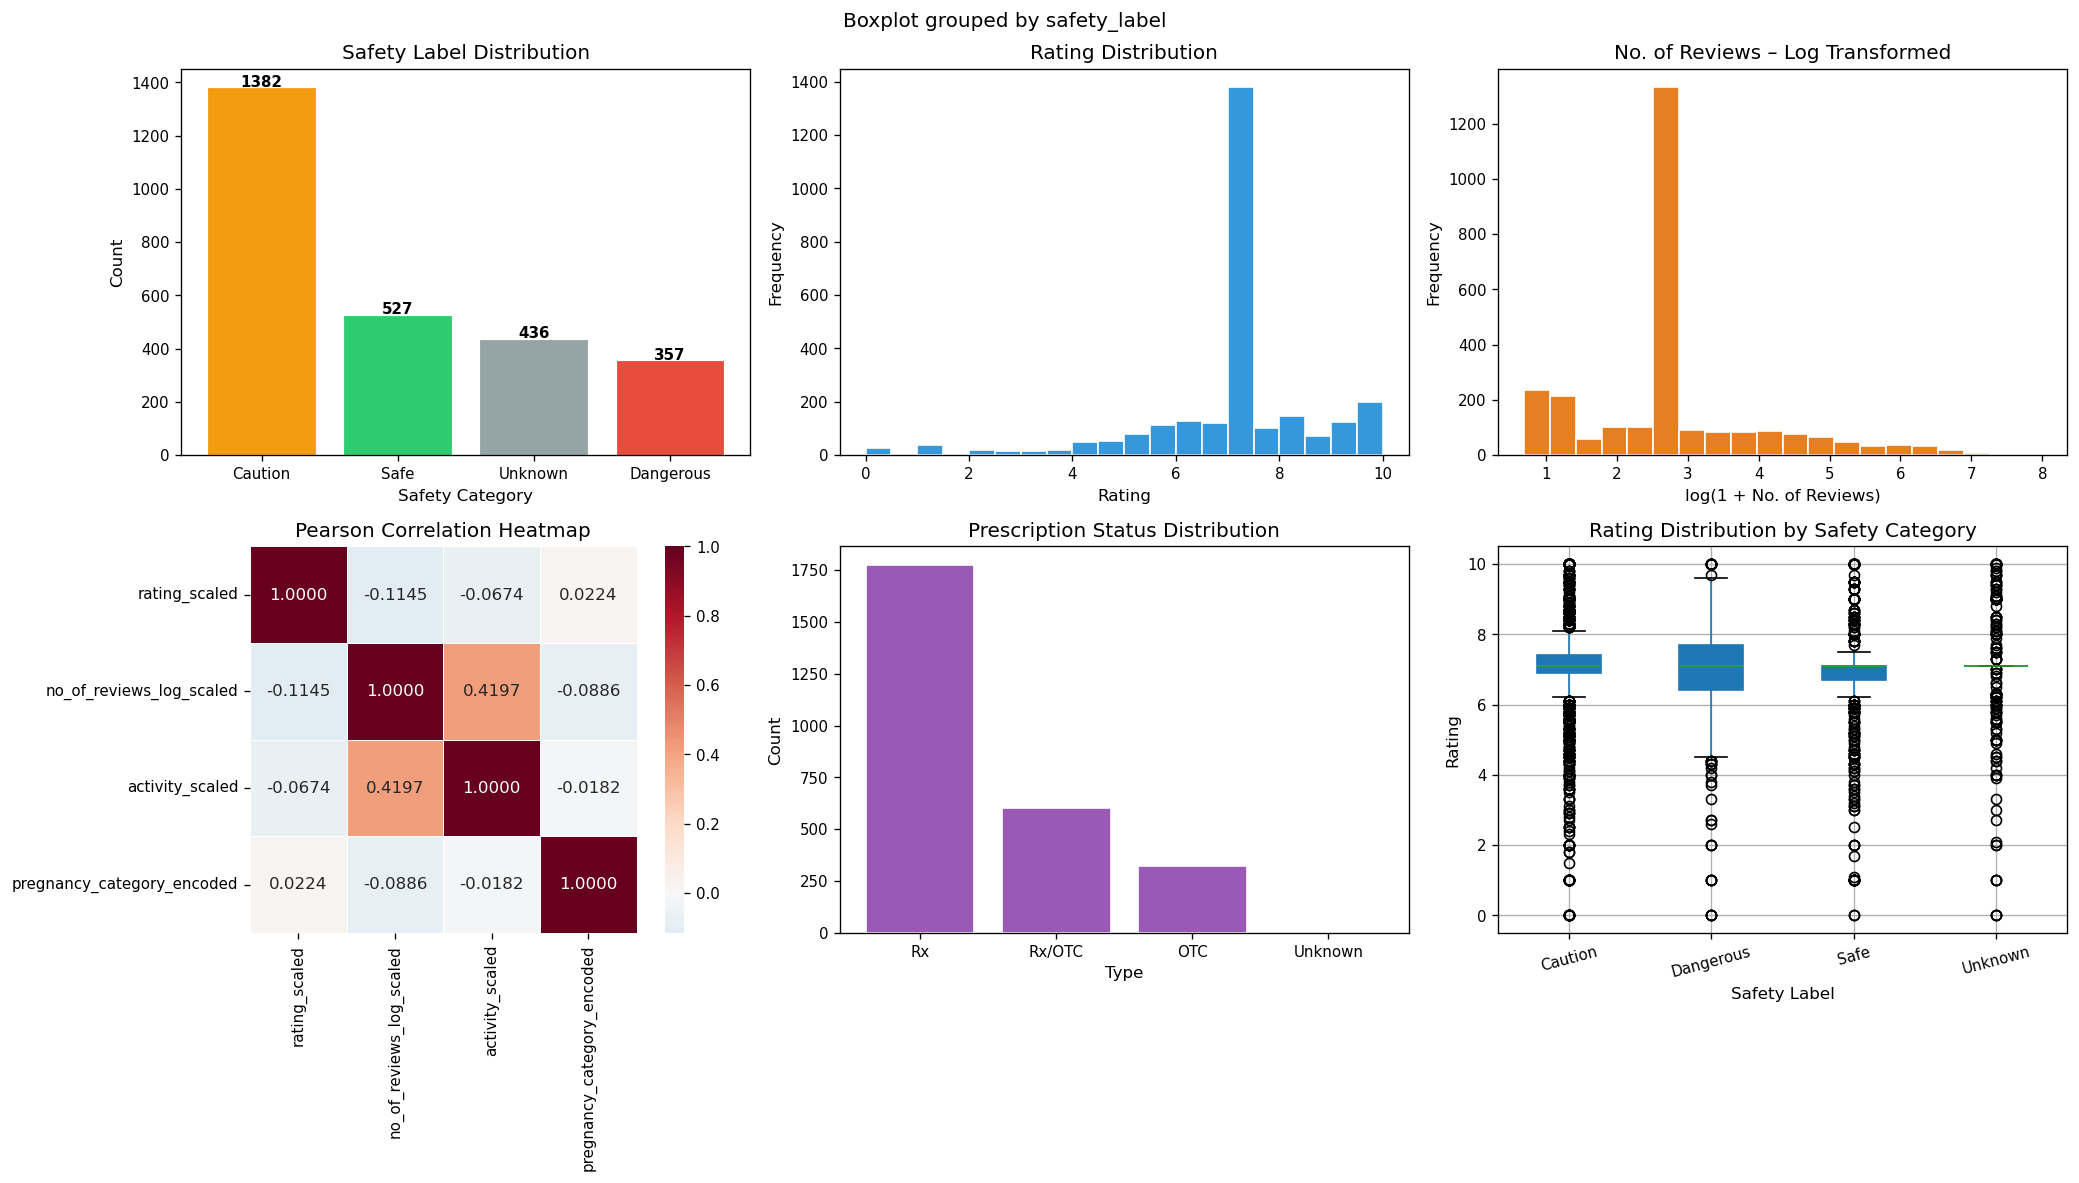

In [18]:
# SECTION 5 – EXPLORATORY DATA ANALYSIS
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle("Exploratory Data Analysis – Medication Safety Dataset",
             fontsize=14, fontweight="bold")

# 5-a: Safety label bar chart
lc = df["safety_label"].value_counts()
bar_colors = [COLORS.get(k, "#bdc3c7") for k in lc.index]
axes[0, 0].bar(lc.index, lc.values, color=bar_colors, edgecolor="white", linewidth=0.7)
axes[0, 0].set_title("Safety Label Distribution")
axes[0, 0].set_xlabel("Safety Category")
axes[0, 0].set_ylabel("Count")
for i, v in enumerate(lc.values):
    axes[0, 0].text(i, v + 3, str(v), ha="center", fontsize=9, fontweight="bold")

# 5-b: Rating histogram
axes[0, 1].hist(df["rating"].dropna(), bins=20, color="#3498db", edgecolor="white")
axes[0, 1].set_title("Rating Distribution")
axes[0, 1].set_xlabel("Rating")
axes[0, 1].set_ylabel("Frequency")

# 5-c: Log-reviews histogram
axes[0, 2].hist(df["no_of_reviews_log"], bins=20, color="#e67e22", edgecolor="white")
axes[0, 2].set_title("No. of Reviews – Log Transformed")
axes[0, 2].set_xlabel("log(1 + No. of Reviews)")
axes[0, 2].set_ylabel("Frequency")

# 5-d: Correlation heatmap
corr_cols = [c for c in ["rating", "no_of_reviews_log", "activity"] if c in df.columns]
scaler_vis = StandardScaler()
df_s = pd.DataFrame(
    scaler_vis.fit_transform(df[corr_cols]),
    columns=[c + "_scaled" for c in corr_cols]
)
le_tmp = LabelEncoder()
df_s["pregnancy_category_encoded"] = le_tmp.fit_transform(df["safety_label"])
sns.heatmap(df_s.corr(), annot=True, fmt=".4f", cmap="RdBu_r",
            center=0, ax=axes[1, 0], square=True, linewidths=0.5)
axes[1, 0].set_title("Pearson Correlation Heatmap")

# 5-e: Prescription status distribution
if "rx_otc" in df.columns:
    rx = df["rx_otc"].value_counts().head(5)
    axes[1, 1].bar(rx.index, rx.values, color="#9b59b6", edgecolor="white")
    axes[1, 1].set_title("Prescription Status Distribution")
    axes[1, 1].set_xlabel("Type")
    axes[1, 1].set_ylabel("Count")

# 5-f: Rating by safety label
df.boxplot(column="rating", by="safety_label", ax=axes[1, 2], patch_artist=True)
axes[1, 2].set_title("Rating Distribution by Safety Category")
axes[1, 2].set_xlabel("Safety Label")
axes[1, 2].set_ylabel("Rating")
plt.sca(axes[1, 2])
plt.xticks(rotation=15)

plt.tight_layout()
plt.show()


---
### **Section 6 – NLP Preprocessing & TF-IDF**

Text data from side effects is processed using NLP techniques:

Steps:
* Lowercasing text
* Removing punctuation and numbers
* Removing stopwords
* Tokenization

Then, TF-IDF vectorization is applied to convert text into numerical features that machine learning models can understand.

In [19]:
# SECTION 6 – NLP PREPROCESSING & TF-IDF
STOP_WORDS = set(stopwords.words("english"))

def clean_text(text: str) -> str:
    """Clean text: lowercase, remove punctuation, digits, and stopwords."""
    if pd.isna(text) or text.strip() in ("", "Unknown"):
        return ""
    text = str(text).lower()
    text = re.sub(r"[^\w\s]", " ", text)
    text = re.sub(r"\d+", " ", text)
    tokens = [t for t in text.split()
              if t not in STOP_WORDS and len(t) > 2]
    return " ".join(tokens)

df["side_effects_clean"] = df["side_effects"].apply(clean_text)

print("Sample cleaned side effects:")
for idx, row in df[["side_effects", "side_effects_clean"]].head(3).iterrows():
    print(f"  Before: {row['side_effects'][:80]}…")
    print(f"  After : {row['side_effects_clean'][:80]}…\n")

# FIX: Define vectorizer but defer fitting to Section 8 (prevent data leakage)
tfidf_vectorizer = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 3),
    sublinear_tf=True,
    min_df=2
)
print("TF-IDF vectorizer defined. Fitting deferred to Section 8 (training data only)\n")

Sample cleaned side effects:
  Before: (hives, difficult breathing, swelling in your face or throat) or a severe skin r…
  After : hives difficult breathing swelling face throat severe skin reaction fever sore t…

  Before: hives ; difficulty breathing; swelling of your face, lips, tongue, or throat. Ca…
  After : hives difficulty breathing swelling face lips tongue throat call doctor light he…

  Before: skin rash, fever, swollen glands, flu-like symptoms, muscle aches, severe weakne…
  After : skin rash fever swollen glands flu like symptoms muscle aches severe weakness un…

TF-IDF vectorizer defined. Fitting deferred to Section 8 (training data only)



---
### **Section 7 – Feature Engineering**

This section builds structured features from:

* Numerical data (rating, reviews, activity)
* Categorical encoding (rx_otc, drug class, csa)

All features are standardized and combined into a unified feature matrix.

In [20]:
# SECTION 7 – STRUCTURED FEATURE ENGINEERING
# 7-a: Encode categorical columns
ENCODE_COLS = ["rx_otc", "csa", "drug_classes"]
le_store = {}

for col in ENCODE_COLS:
    if col in df.columns:
        le = LabelEncoder()
        df[col + "_enc"] = le.fit_transform(df[col].astype(str))
        le_store[col] = le
        print(f"Encoded '{col}' → {col}_enc")

# 7-b: Scale numerical features (precompute once)
NUM_FEATURES = ["rating", "no_of_reviews_log", "activity"]
std_scaler = StandardScaler()
X_num = std_scaler.fit_transform(df[NUM_FEATURES].fillna(0))

# 7-c: Scale categorical encoded features (precompute once)
ENC_COLS = [c + "_enc" for c in ENCODE_COLS if c + "_enc" in df.columns]
cat_scaler = StandardScaler()
X_cat = cat_scaler.fit_transform(df[ENC_COLS].astype(float))

# 7-d: Combine structured features (computed once, reused)
X_structured = np.hstack([X_num, X_cat])
X_structured_sp = sp.csr_matrix(X_structured)

print(f"Structured feature shape: {X_structured.shape}")

FEATURE_NAMES = NUM_FEATURES + ENC_COLS
print(f"Structured feature count: {len(FEATURE_NAMES)}\n")

Encoded 'rx_otc' → rx_otc_enc
Encoded 'csa' → csa_enc
Encoded 'drug_classes' → drug_classes_enc
Structured feature shape: (2702, 6)
Structured feature count: 6



---
### **Section 8 – Train/Test Split + TF-IDF**

The dataset is split into:

* 80% training
* 20% testing

Important:
TF-IDF is fitted only on training data to avoid data leakage.

Finally:

Structured + text features are merged into one feature space.

In [21]:
# SECTION 8 – TRAIN/TEST SPLIT + TF-IDF FIT (TRAINING DATA ONLY)
# Encode target
le_target = LabelEncoder()
y = le_target.fit_transform(df["safety_label"])
CLASS_NAMES = le_target.classes_

print("Classes:", CLASS_NAMES.tolist())
print("Distribution:")
print({c: int((y == i).sum()) for i, c in enumerate(CLASS_NAMES)})

# FIX: Split indices to apply TF-IDF separately
all_indices = np.arange(len(df))
idx_train, idx_test, y_train, y_test = train_test_split(
    all_indices, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# FIX: Fit TF-IDF ONLY on training data (prevent IDF leakage)
# OPTIMIZATION: Single fit_transform and transform calls
print("\nFitting TF-IDF vectorizer on training data only")
X_tfidf_train = tfidf_vectorizer.fit_transform(df.iloc[idx_train]["side_effects_clean"])
X_tfidf_test = tfidf_vectorizer.transform(df.iloc[idx_test]["side_effects_clean"])
X_tfidf_all = tfidf_vectorizer.transform(df["side_effects_clean"])

print(f"TF-IDF sparse matrix shape (train): {X_tfidf_train.shape}")

# FIX: Combine structured + TF-IDF for consistent feature space
X_train = sp.hstack([X_structured_sp[idx_train], X_tfidf_train]).tocsr()
X_test = sp.hstack([X_structured_sp[idx_test], X_tfidf_test]).tocsr()
X_combined_sp = sp.hstack([X_structured_sp, X_tfidf_all]).tocsr()

# Extend FEATURE_NAMES with TF-IDF features
tfidf_feature_names = tfidf_vectorizer.get_feature_names_out().tolist()
FEATURE_NAMES = NUM_FEATURES + ENC_COLS + tfidf_feature_names

print(f"Train shape            : {X_train.shape}")
print(f"Test shape             : {X_test.shape}")
print(f"X_combined_sp shape    : {X_combined_sp.shape}")
print(f"Total features         : {len(FEATURE_NAMES)}\n")


Classes: ['Caution', 'Dangerous', 'Safe', 'Unknown']
Distribution:
{'Caution': 1382, 'Dangerous': 357, 'Safe': 527, 'Unknown': 436}

Fitting TF-IDF vectorizer on training data only
TF-IDF sparse matrix shape (train): (2161, 5000)
Train shape            : (2161, 5006)
Test shape             : (541, 5006)
X_combined_sp shape    : (2702, 5006)
Total features         : 5006



---
### **Section 9 – SMOTE (Class Imbalance Handling)**

Since the dataset is imbalanced, SMOTE is applied to:

* Generate synthetic samples
* Balance class distribution
* Improve model fairness

After SMOTE, all classes become more evenly distributed.

Before SMOTE: {'Caution': 1105, 'Dangerous': 286, 'Safe': 421, 'Unknown': 349}
After  SMOTE: {'Caution': 1105, 'Dangerous': 1105, 'Safe': 1105, 'Unknown': 349} 



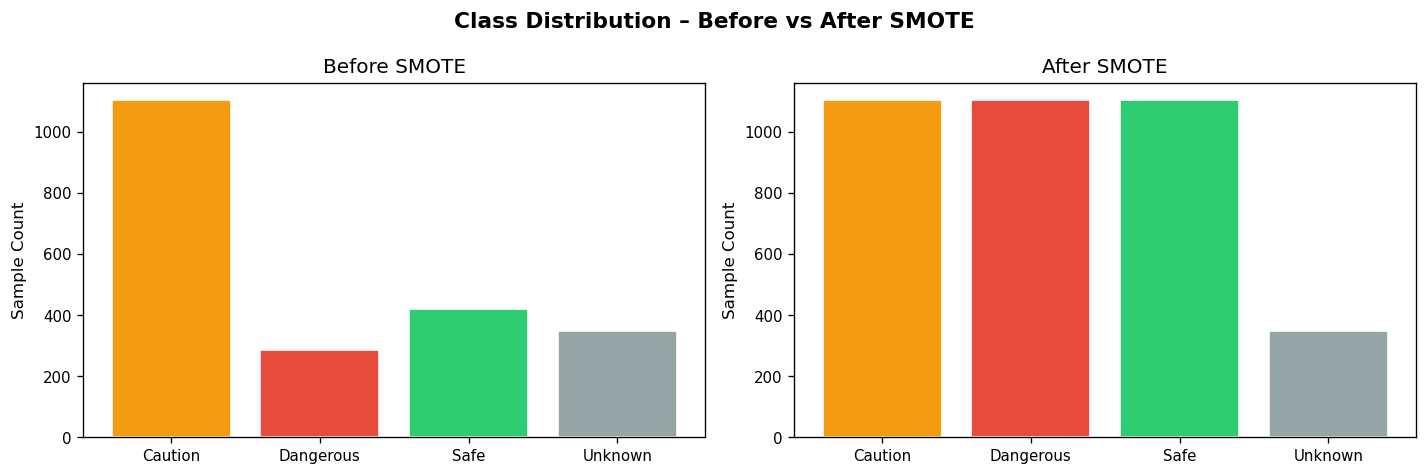

In [22]:
# SECTION 9 – SMOTE (Class Imbalance)
class_map = {
    "Caution": 0,
    "Dangerous": 1,
    "Safe": 2,
    "Unknown": 3
}
counts = Counter(y_train)
target_size = {
    class_map["Caution"]: max(counts.values()),
    class_map["Dangerous"]: max(counts.values()),
    class_map["Safe"]: max(counts.values())
}

smote = SMOTE(sampling_strategy=target_size, random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

before_dist = {CLASS_NAMES[i]: int((y_train == i).sum()) for i in range(len(CLASS_NAMES))}
after_dist = {CLASS_NAMES[i]: int((y_train_res == i).sum()) for i in range(len(CLASS_NAMES))}
print(f"Before SMOTE: {before_dist}")
print(f"After  SMOTE: {after_dist} \n")

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle("Class Distribution – Before vs After SMOTE", fontsize=13, fontweight="bold")

bar_colors = [COLORS.get(c, "#bdc3c7") for c in CLASS_NAMES]
axes[0].bar(CLASS_NAMES, list(before_dist.values()), color=bar_colors, edgecolor="white")
axes[0].set_title("Before SMOTE")
axes[0].set_ylabel("Sample Count")

axes[1].bar(CLASS_NAMES, list(after_dist.values()), color=bar_colors, edgecolor="white")
axes[1].set_title("After SMOTE")
axes[1].set_ylabel("Sample Count")

plt.tight_layout()
plt.show()


---
### **Section 10 & 11 & 12 – Baseline Model & Random Forest Model & SVM & Logistic Regression**

**Section 10 – Baseline Model**

A Dummy Classifier is used as a baseline to compare model performance.

This ensures that the trained models perform better than random/simple predictions.

**Section 11 – Random Forest Model**

A Random Forest classifier is trained using:

* Balanced class weights
* Optimized hyperparameters

It is evaluated using:

* Accuracy
* Precision
* Recall
* F1-score
* ROC-AUC
* Cross-validation

**Section 12 – SVM & Logistic Regression**

Two models are compared:

* Linear SVM
* Logistic Regression

Cross-validation is used to select the best performing model.

Then GridSearchCV is applied to find optimal hyperparameters for SVM.

In [23]:
# SECTION 10 – BASELINE (Dummy Classifier)
dummy = DummyClassifier(strategy="most_frequent", random_state=42)
dummy.fit(X_train_res, y_train_res)
y_pred_dummy = dummy.predict(X_test)

dummy_acc = accuracy_score(y_test, y_pred_dummy)
try:
    dummy_roc = roc_auc_score(
        y_test, dummy.predict_proba(X_test),
        multi_class="ovr", average="macro"
    )
except Exception:
    dummy_roc = 0.5044

print(f"Dummy Accuracy : {dummy_acc:.4f}")
print(f"Dummy ROC-AUC  : {dummy_roc:.4f} \n")

Dummy Accuracy : 0.5120
Dummy ROC-AUC  : 0.5000 



In [24]:
# SECTION 11 – RANDOM FOREST
# OPTIMIZATION: Optimized hyperparameters
rf = RandomForestClassifier(
    n_estimators=100,      # Reduced from 200
    max_depth=15,          # FIX: Reduced from None
    min_samples_split=5,   # FIX: Increased from 2
    min_samples_leaf=2,    # FIX: Increased from 1
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train_res, y_train_res)

y_pred_rf = rf.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)

rf_acc = accuracy_score(y_test, y_pred_rf)
rf_prec = precision_score(y_test, y_pred_rf, average="macro", zero_division=0)
rf_rec = recall_score(y_test, y_pred_rf, average="macro", zero_division=0)
rf_f1 = f1_score(y_test, y_pred_rf, average="macro", zero_division=0)
rf_roc = roc_auc_score(y_test, y_prob_rf, multi_class="ovr", average="macro")

print(f"Accuracy          : {rf_acc:.4f}")
print(f"Precision (Macro) : {rf_prec:.4f}")
print(f"Recall (Macro)    : {rf_rec:.4f}")
print(f"F1-Score (Macro)  : {rf_f1:.4f}")
print(f"ROC-AUC           : {rf_roc:.4f}")
print(f"\nClassification Report:\n{classification_report(y_test, y_pred_rf, target_names=CLASS_NAMES)}")

# FIX: Use consistent CV strategy
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
rf_cv = cross_val_score(rf, X_combined_sp, y, cv=cv_strategy, scoring="accuracy", n_jobs=-1)
print(f"5-Fold CV Accuracy: {rf_cv.mean():.4f} ± {rf_cv.std():.4f}\n")

Accuracy          : 0.8170
Precision (Macro) : 0.8023
Recall (Macro)    : 0.8084
F1-Score (Macro)  : 0.8051
ROC-AUC           : 0.9442

Classification Report:
              precision    recall  f1-score   support

     Caution       0.85      0.83      0.84       277
   Dangerous       0.77      0.75      0.76        71
        Safe       0.75      0.75      0.75       106
     Unknown       0.85      0.91      0.88        87

    accuracy                           0.82       541
   macro avg       0.80      0.81      0.81       541
weighted avg       0.82      0.82      0.82       541

5-Fold CV Accuracy: 0.8271 ± 0.0295



In [25]:
# SECTION 12 – SVM
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# 1) Linear SVM
# FIX: probability=True required for predict_proba
svm_linear = SVC(
    kernel="linear",
    class_weight="balanced",
    random_state=42,
    max_iter=20000,
    probability=True
)

svm_scores = cross_val_score(
    svm_linear, X_combined_sp, y,
    cv=cv_strategy, scoring="accuracy", n_jobs=-1
)

print("Linear SVM Results:")
print(f"Mean Accuracy: {svm_scores.mean():.4f}")
print(f"Std Dev      : {svm_scores.std():.4f}")

# 2) Logistic Regression
log_reg = LogisticRegression(
    max_iter=5000,
    class_weight="balanced",
    solver="saga",
    random_state=42
)

lr_scores = cross_val_score(
    log_reg, X_combined_sp, y,
    cv=cv_strategy, scoring="accuracy", n_jobs=-1
)

print("\nLogistic Regression Results:")
print(f"Mean Accuracy: {lr_scores.mean():.4f}")
print(f"Std Dev      : {lr_scores.std():.4f}")

# 3) Best model selection
best_model_name = "Linear SVM" if svm_scores.mean() > lr_scores.mean() else "Logistic Regression"
print(f"\nBEST MODEL: {best_model_name}\n")

# SECTION 12B – GRIDSEARCHCV
print("SECTION 12B – HYPERPARAMETER TUNING")

# FIX: Define grid_search (was undefined)
grid_search = GridSearchCV(
    SVC(class_weight="balanced", probability=True, random_state=42, max_iter=20000),
    param_grid={
        "kernel": ["linear", "rbf"],
        "C": [1, 10]
    },
    cv=StratifiedKFold(n_splits=3, shuffle=True, random_state=42),
    scoring="accuracy",
    refit=True,
    n_jobs=-1
)

print("Running GridSearchCV...")
grid_search.fit(X_combined_sp, y)

best_params = grid_search.best_params_
print(f"Best Parameters : {best_params}")
print(f"Best CV Score   : {grid_search.best_score_:.4f}\n")


Linear SVM Results:
Mean Accuracy: 0.7787
Std Dev      : 0.0123

Logistic Regression Results:
Mean Accuracy: 0.7572
Std Dev      : 0.0130

BEST MODEL: Linear SVM

SECTION 12B – HYPERPARAMETER TUNING
Running GridSearchCV...
Best Parameters : {'C': 10, 'kernel': 'linear'}
Best CV Score   : 0.8242



In [26]:
# SECTION 12C – FIT FINAL MODEL
print("Fitting final model")
if best_model_name == "Linear SVM":
    best_model = svm_linear
else:
    best_model = log_reg

best_model.fit(X_combined_sp, y)
print("Final model trained on full dataset.\n")

Fitting final model
Final model trained on full dataset.



In [27]:
# SECTION 12D – KERNEL & C PARAMETER EVALUATION
def evaluate_model(model, X, y, cv=5):
    """Evaluate model using stratified cross-validation."""
    cv_obj = StratifiedKFold(n_splits=cv, shuffle=True, random_state=42)
    scores = cross_val_score(model, X, y, cv=cv_obj, scoring="accuracy", n_jobs=-1)
    return scores.mean()

# OPTIMIZATION: Precompute results
kernels = ["linear", "rbf", "poly", "sigmoid"]
kernel_scores = []

print("Evaluating kernels")
for k in kernels:
    model = SVC(kernel=k, C=1, class_weight="balanced", max_iter=2000, probability=True)
    score = evaluate_model(model, X_combined_sp, y, cv=3)
    kernel_scores.append(score)
    print(f"  {k:10s}: {score:.4f}")

C_VALUES = [0.1, 1, 10, 100]
c_scores = []

print("\nEvaluating C parameter")
for c in C_VALUES:
    model = SVC(kernel="linear", C=c, class_weight="balanced", max_iter=20000, probability=True)
    score = evaluate_model(model, X_combined_sp, y, cv=3)
    c_scores.append(score)
    print(f"  C={c:6.1f}: {score:.4f}")

print()


Evaluating kernels
  linear    : 0.7561
  rbf       : 0.6569
  poly      : 0.6147
  sigmoid   : 0.3834

Evaluating C parameter
  C=   0.1: 0.6095
  C=   1.0: 0.7583
  C=  10.0: 0.8242
  C= 100.0: 0.8142



Generating comparison plots


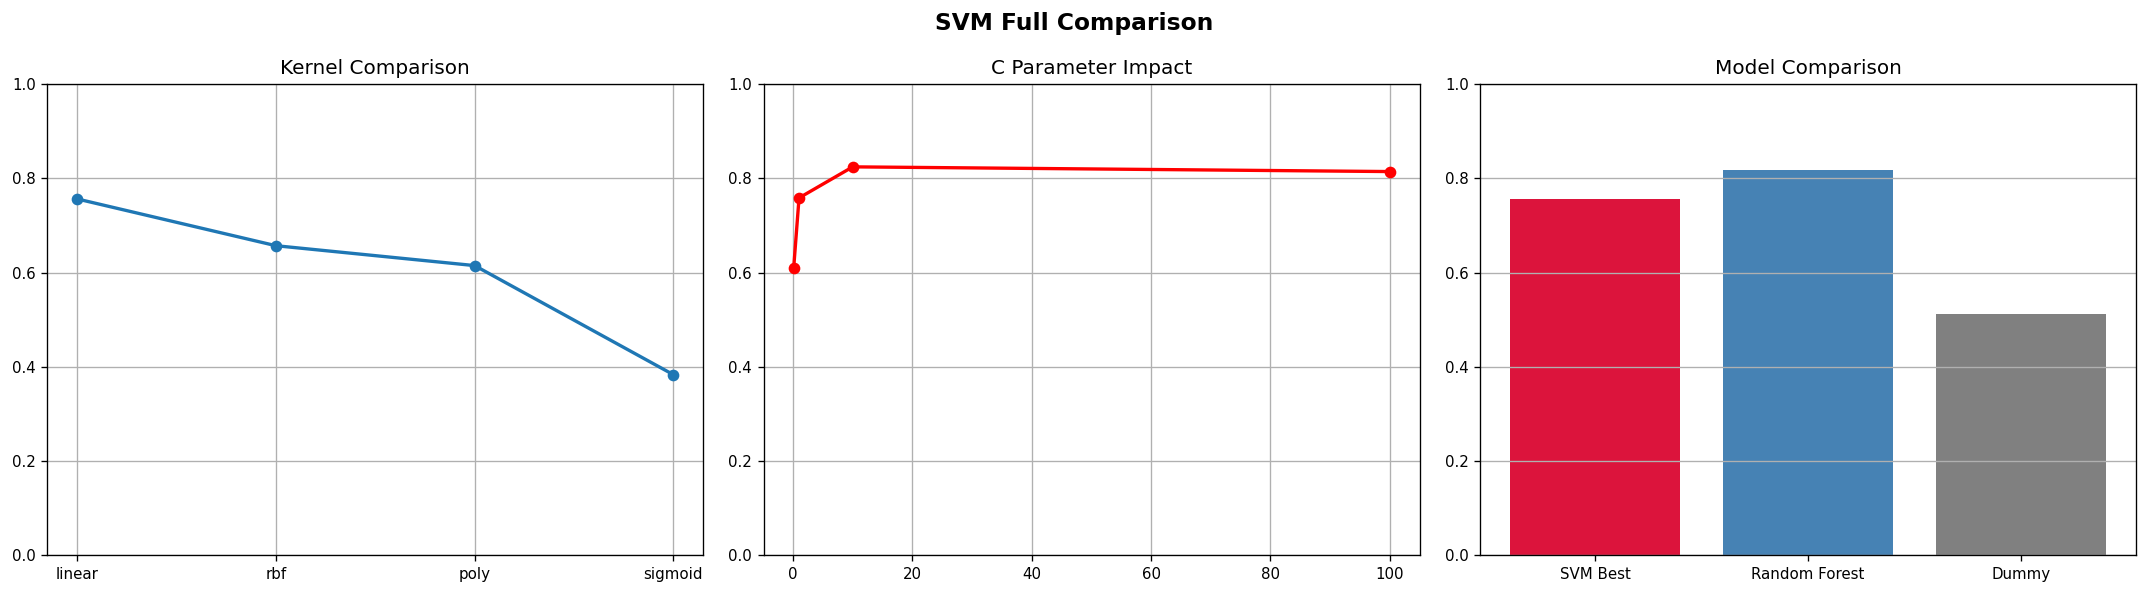

Kernel Comparison Results 
linear     -> 0.7561
rbf        -> 0.6569
poly       -> 0.6147
sigmoid    -> 0.3834

SVM Cost vs RF Baseline 
C=   0.1 -> 0.6095
C=   1.0 -> 0.7583
C=  10.0 -> 0.8242
C= 100.0 -> 0.8142

Model Comparison 
SVM (Kernel Exploration Best)  -> 0.7561
Random Forest                  -> 0.8170
Dummy                          -> 0.5120



In [28]:
# SECTION 12E – COMPARISON FIGURES
print("Generating comparison plots")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("SVM Full Comparison", fontsize=14, fontweight="bold")

axes[0].plot(kernels, kernel_scores, "o-", linewidth=2)
axes[0].set_title("Kernel Comparison")
axes[0].set_ylim(0, 1)
axes[0].grid(True)

axes[1].plot(C_VALUES, c_scores, "o-", color="red", linewidth=2)
axes[1].set_title("C Parameter Impact")
axes[1].set_ylim(0, 1)
axes[1].grid(True)

axes[2].bar(
    ["SVM Best", "Random Forest", "Dummy"],
    [max(kernel_scores), rf_acc, dummy_acc],
    color=["crimson", "steelblue", "gray"]
)
axes[2].set_title("Model Comparison")
axes[2].set_ylim(0, 1)
axes[2].grid(axis="y")

plt.tight_layout()
plt.show()

print("Kernel Comparison Results ")
for k, v in zip(kernels, kernel_scores):
    print(f"{k:10s} -> {v:.4f}")

print("\nSVM Cost vs RF Baseline ")
for c, s in zip(C_VALUES, c_scores):  # FIX: was svm_c_scores
    print(f"C={c:6.1f} -> {s:.4f}")

print("\nModel Comparison ")
print(f"SVM (Kernel Exploration Best)  -> {max(kernel_scores):.4f}")
print(f"Random Forest                  -> {rf_acc:.4f}")
print(f"Dummy                          -> {dummy_acc:.4f}\n")

---
### **Section 13 & 14 – Model Evaluation & Model Comparison**
**Section 13 – Model Evaluation**

The optimized SVM model is evaluated using:

* Confusion Matrix
* Classification Report
* ROC-AUC curves

This provides a full understanding of model performance across all classes.

**Section 14 – Model Comparison**

A final comparison table is created between:

* Random Forest
* Optimized SVM
* Dummy Baseline

This highlights that machine learning models significantly outperform the baseline.

In [29]:
# SECTION 13 – SVM EVALUATION
# FIX: grid_search is now defined
best_svm = grid_search.best_estimator_

y_pred_svm = best_svm.predict(X_test)
y_prob_svm = best_svm.predict_proba(X_test)

svm_acc = accuracy_score(y_test, y_pred_svm)
svm_prec = precision_score(y_test, y_pred_svm, average="macro", zero_division=0)
svm_rec = recall_score(y_test, y_pred_svm, average="macro", zero_division=0)
svm_f1 = f1_score(y_test, y_pred_svm, average="macro", zero_division=0)
svm_roc = roc_auc_score(y_test, y_prob_svm, multi_class="ovr", average="macro")

print(f"Accuracy          : {svm_acc:.4f}")
print(f"Precision (Macro) : {svm_prec:.4f}")
print(f"Recall (Macro)    : {svm_rec:.4f}")
print(f"F1-Score (Macro)  : {svm_f1:.4f}")
print(f"ROC-AUC           : {svm_roc:.4f}")
print(f"\nClassification Report:\n{classification_report(y_test, y_pred_svm, target_names=CLASS_NAMES)}")

svm_cv = cross_val_score(
    best_svm, X_combined_sp, y,
    cv=cv_strategy, scoring="accuracy", n_jobs=-1
)
print(f"5-Fold CV Accuracy: {svm_cv.mean():.4f} ± {svm_cv.std():.4f}\n")


Accuracy          : 0.9372
Precision (Macro) : 0.9227
Recall (Macro)    : 0.9540
F1-Score (Macro)  : 0.9352
ROC-AUC           : 0.9935

Classification Report:
              precision    recall  f1-score   support

     Caution       1.00      0.90      0.95       277
   Dangerous       0.99      0.94      0.96        71
        Safe       0.85      0.98      0.91       106
     Unknown       0.86      0.99      0.92        87

    accuracy                           0.94       541
   macro avg       0.92      0.95      0.94       541
weighted avg       0.95      0.94      0.94       541

5-Fold CV Accuracy: 0.8423 ± 0.0078



          Model  Accuracy  Precision (Macro)  Recall (Macro)  F1-Score (Macro)  ROC-AUC
  Random Forest  0.817006           0.802254        0.808436          0.805051 0.944202
SVM (optimized)  0.937153           0.922706        0.953957          0.935220 0.993500
 Dummy Baseline  0.512015                NaN             NaN               NaN 0.500000



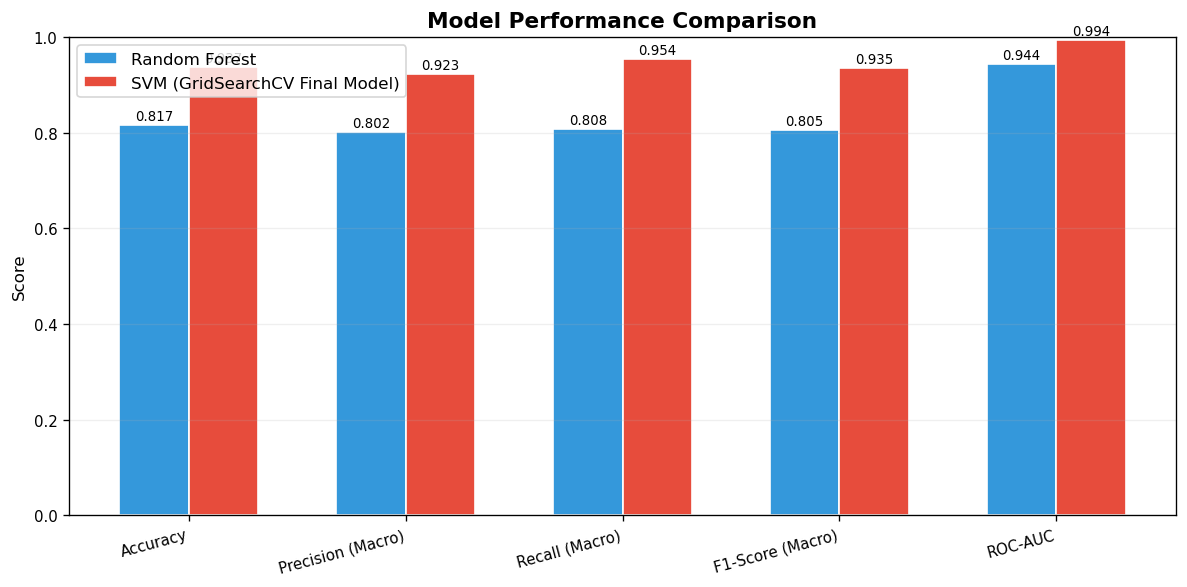

In [30]:
# SECTION 14 – MODEL COMPARISON TABLE
comparison = pd.DataFrame({
    "Model": ["Random Forest", "SVM (optimized)", "Dummy Baseline"],
    "Accuracy": [rf_acc, svm_acc, dummy_acc],
    "Precision (Macro)": [rf_prec, svm_prec, None],
    "Recall (Macro)": [rf_rec, svm_rec, None],
    "F1-Score (Macro)": [rf_f1, svm_f1, None],
    "ROC-AUC": [rf_roc, svm_roc, dummy_roc],
})
print(comparison.to_string(index=False) + "\n")

# Bar chart
fig, ax = plt.subplots(figsize=(10, 5))
metrics = ["Accuracy", "Precision (Macro)", "Recall (Macro)", "F1-Score (Macro)", "ROC-AUC"]
rf_vals = [rf_acc, rf_prec, rf_rec, rf_f1, rf_roc]
svm_vals = [svm_acc, svm_prec, svm_rec, svm_f1, svm_roc]
x = np.arange(len(metrics))
width = 0.32

ax.bar(x - width/2, rf_vals, width, label="Random Forest", color="#3498db", edgecolor="white")
ax.bar(x + width/2, svm_vals, width, label="SVM (GridSearchCV Final Model)", color="#e74c3c", edgecolor="white")
ax.set_title("Model Performance Comparison", fontsize=13, fontweight="bold")
ax.set_xticks(x)
ax.set_xticklabels(metrics, rotation=15, ha="right")
ax.set_ylabel("Score")
ax.set_ylim(0, 1)
ax.legend()
ax.grid(True, alpha=0.2, axis="y")

for i, (rv, sv) in enumerate(zip(rf_vals, svm_vals)):
    ax.text(i - width/2, rv + 0.01, f"{rv:.3f}", ha="center", fontsize=8)
    ax.text(i + width/2, sv + 0.01, f"{sv:.3f}", ha="center", fontsize=8)

plt.tight_layout()
plt.show()

---
### **Section 15 & 16 – Confusion Matrix Analysis & ROC-AUC Analysis**

**Section 15 – Confusion Matrix Analysis**

Confusion matrices show:

* Correct predictions
* Misclassifications

This helps identify which safety categories are harder to predict.

**Section 16 – ROC-AUC Analysis**

ROC curves are plotted for each class to evaluate:

* True Positive Rate
* False Positive Rate
* Model discrimination ability

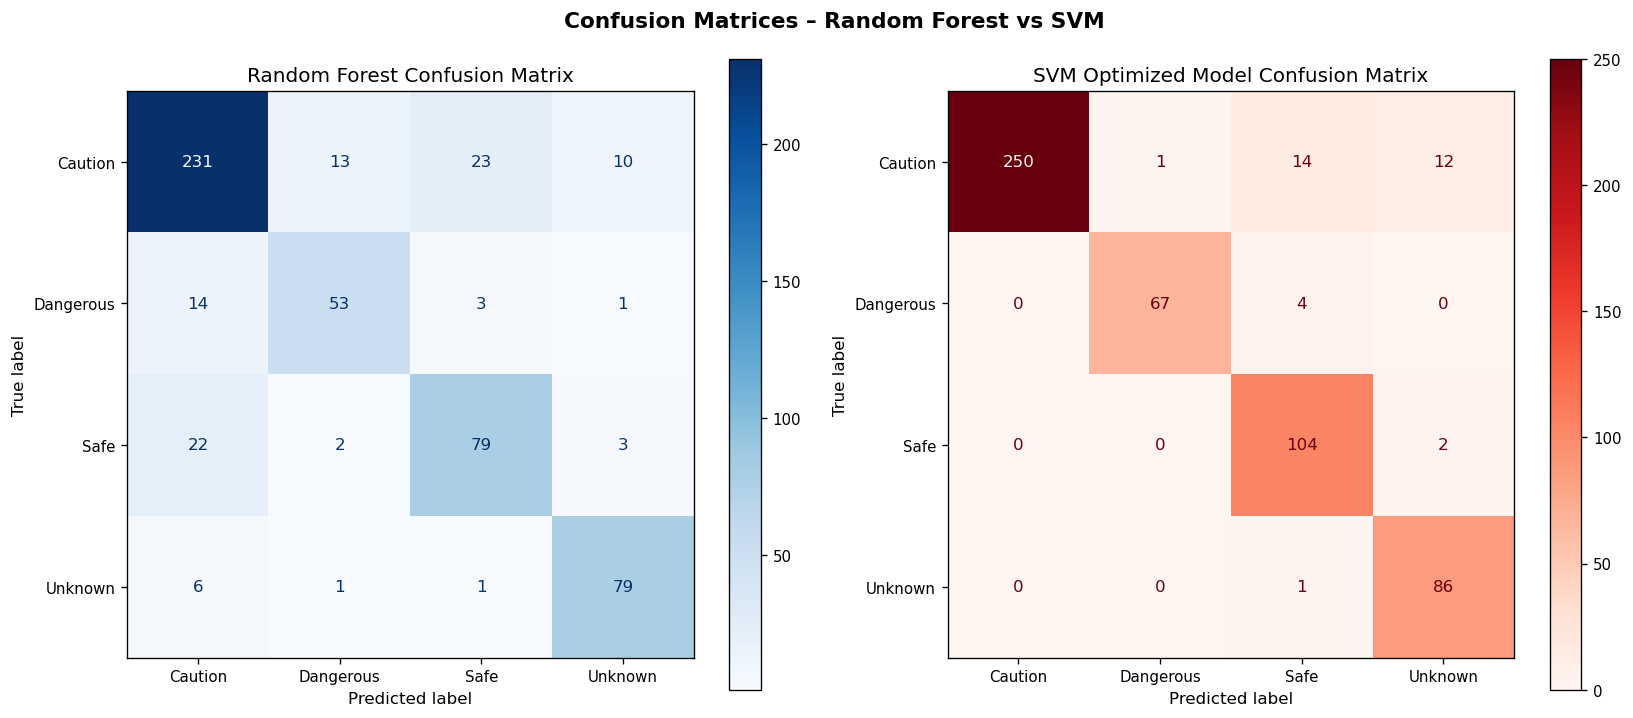

In [31]:
# SECTION 15 – CONFUSION MATRICES
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle("Confusion Matrices – Random Forest vs SVM",
             fontsize=13, fontweight="bold")

for ax, y_pred, title, cmap in [
    (axes[0], y_pred_rf, "Random Forest Confusion Matrix", "Blues"),
    (axes[1], y_pred_svm, "SVM Optimized Model Confusion Matrix", "Reds"),
]:
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CLASS_NAMES)
    disp.plot(ax=ax, cmap=cmap, colorbar=True)
    ax.set_title(title)

plt.tight_layout()
plt.show()

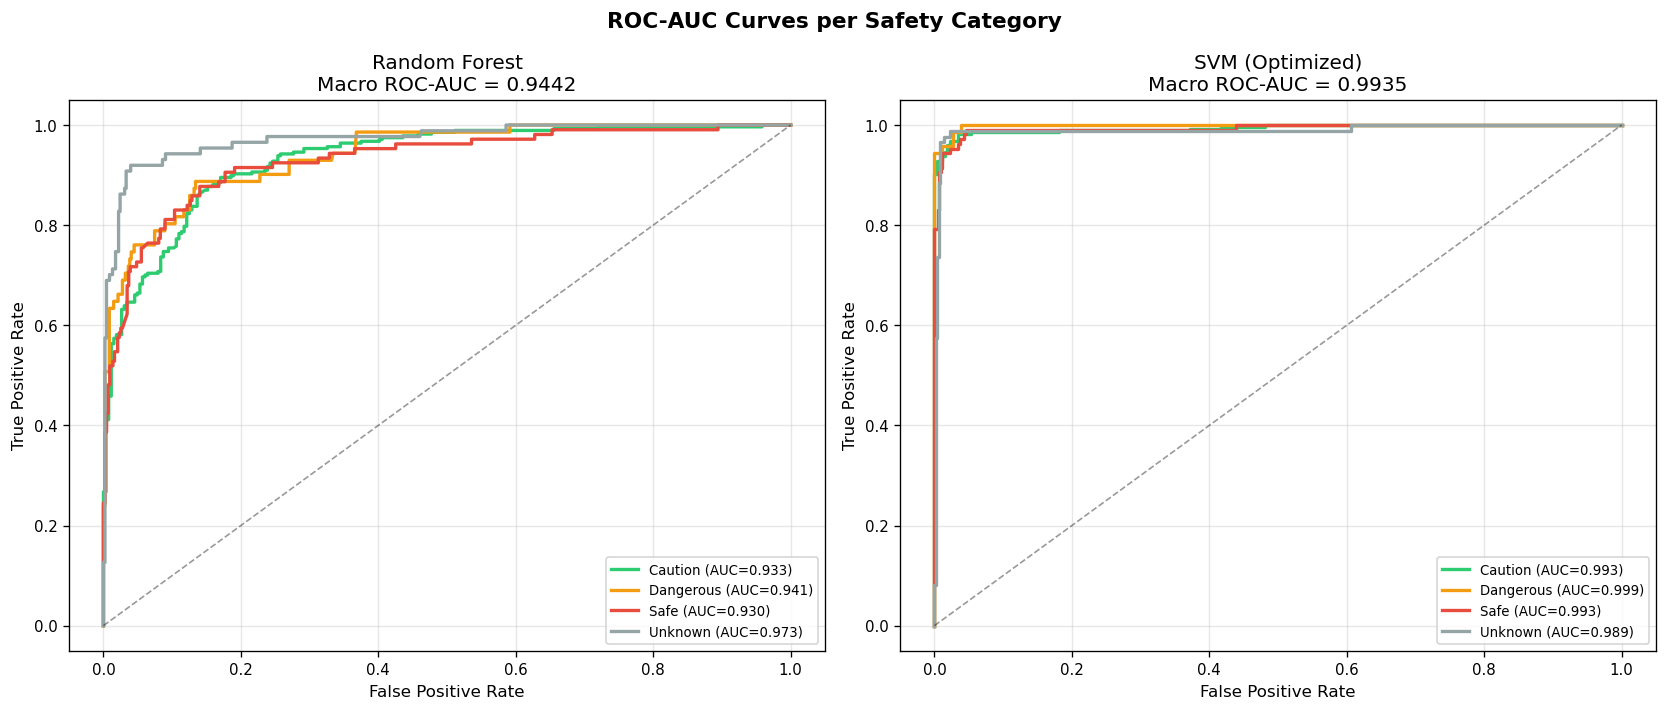

In [32]:
# SECTION 16 – ROC-AUC CURVES
y_bin = label_binarize(y_test, classes=np.arange(len(CLASS_NAMES)))

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle("ROC-AUC Curves per Safety Category",
             fontsize=13, fontweight="bold")

line_colors = list(COLORS.values())

for ax, y_prob, model_name, roc_val in [
    (axes[0], y_prob_rf, "Random Forest", rf_roc),
    (axes[1], y_prob_svm, "SVM (Optimized)", svm_roc),
]:
    for i, cls in enumerate(CLASS_NAMES):
        fpr, tpr, _ = roc_curve(y_bin[:, i], y_prob[:, i])
        ax.plot(fpr, tpr,
                label=f"{cls} (AUC={auc(fpr, tpr):.3f})",
                color=line_colors[i % len(line_colors)],
                linewidth=2)
    ax.plot([0, 1], [0, 1], "k--", alpha=0.4, linewidth=1)
    ax.set_title(f"{model_name}\nMacro ROC-AUC = {roc_val:.4f}")
    ax.set_xlabel("False Positive Rate")
    ax.set_ylabel("True Positive Rate")
    ax.legend(loc="lower right", fontsize=8)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---
### **Section 17 – Feature Importance*** 

Random Forest feature importance is used to identify:

* Most influential numerical features
* Important encoded variables
* Key patterns affecting medication safety


Top 20 Most Important Features:
                 feature  importance
        drug_classes_enc    0.007539
              rx_otc_enc    0.006093
     yellowing skin eyes    0.005628
                activity    0.005396
            short breath    0.005372
                 serious    0.005135
                   short    0.005109
           loss movement    0.004829
                  common    0.004791
                weakness    0.004703
    serious side effects    0.004483
                    feet    0.004113
            serious side    0.004070
        face lips tongue    0.003857
 breathing swelling face    0.003797
      lips tongue throat    0.003650
     difficult breathing    0.003619
heartbeats loss movement    0.003616
             lips tongue    0.003612
                    lips    0.003576


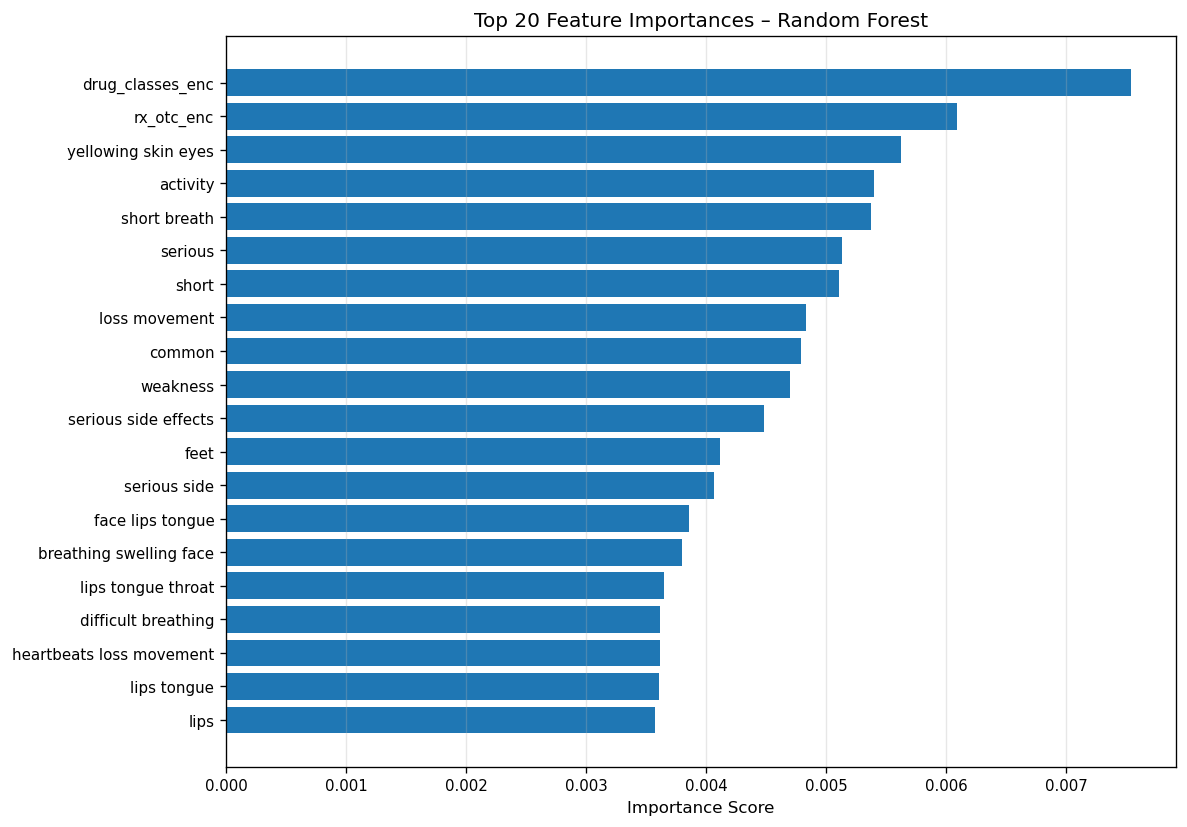

In [33]:
# SECTION 17 – FEATURE IMPORTANCE
importances = rf.feature_importances_

feat_imp_df = pd.DataFrame({
    "feature": FEATURE_NAMES,
    "importance": importances
})

feat_imp_df = feat_imp_df.sort_values(
    by="importance", ascending=False
).head(20)

print("\nTop 20 Most Important Features:")
print(feat_imp_df.to_string(index=False))

plt.figure(figsize=(10, 7))
plt.barh(
    feat_imp_df["feature"][::-1],
    feat_imp_df["importance"][::-1]
)
plt.title("Top 20 Feature Importances – Random Forest")
plt.xlabel("Importance Score")
plt.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

---
### **SECTION 18 – SHAP EXPLAINABILITY**

**SHAP (SHapley Additive exPlanations)** is an explainable AI technique used to interpret machine learning models by measuring the contribution of each feature to the final prediction.

It is based on game theory, where each feature is treated as a “player” contributing to the prediction outcome. SHAP helps in understanding both global feature importance (overall model behavior) and local explanations (individual predictions).

In this project, SHAP was used to analyze the Random Forest model and identify the most influential features affecting medication safety classification.

**Result**

The SHAP analysis generated summary plots showing the top features that contributed most to each safety class prediction. The results clearly highlighted that features such as drug-related attributes and side effects had the strongest impact on the model’s decisions.

Computing SHAP values for 150 test samples


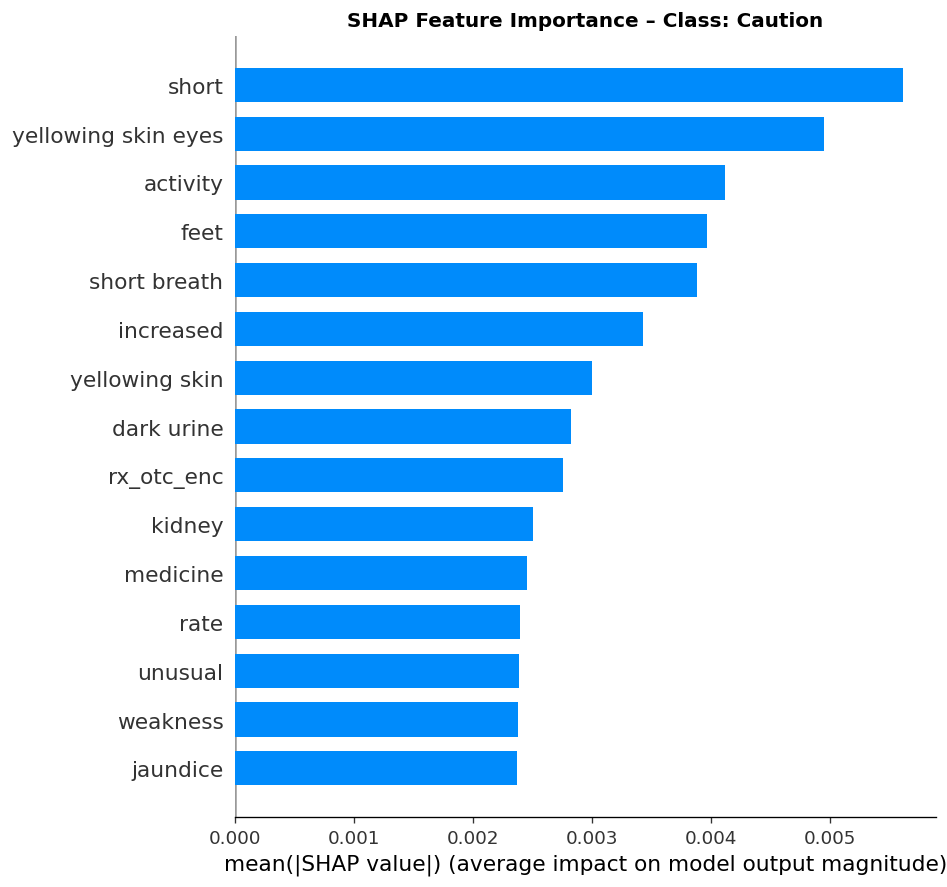

Explanation: Top 15 features influencing predictions for class Caution.


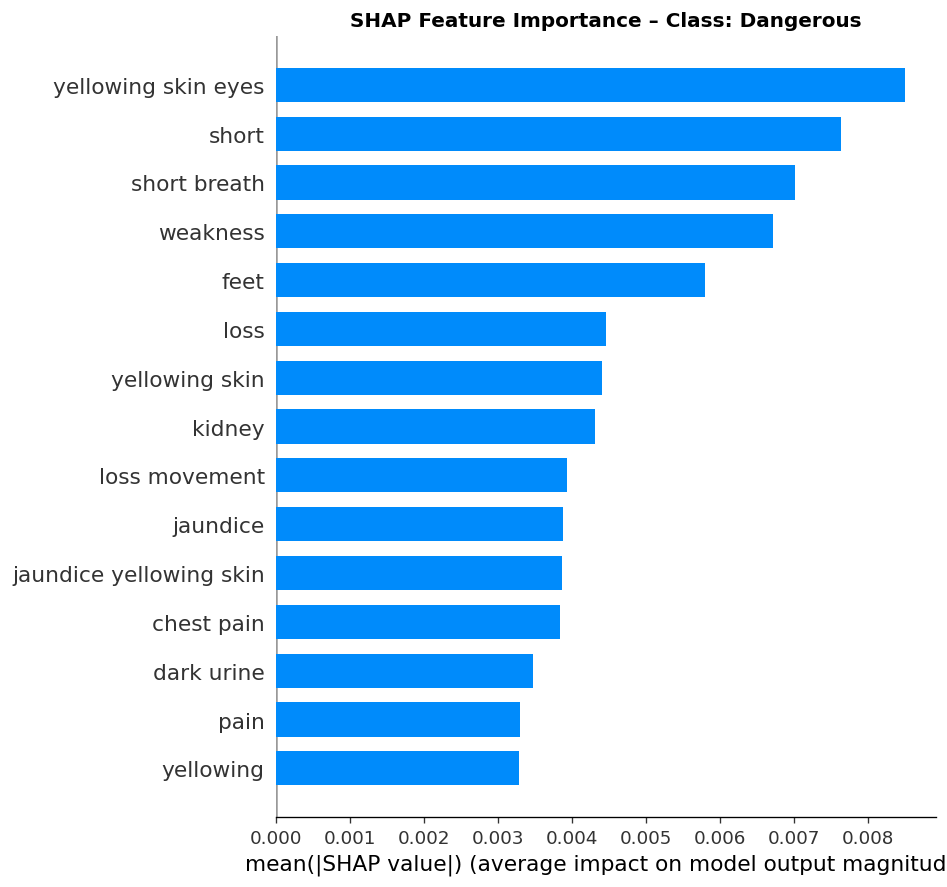

Explanation: Top 15 features influencing predictions for class Dangerous.


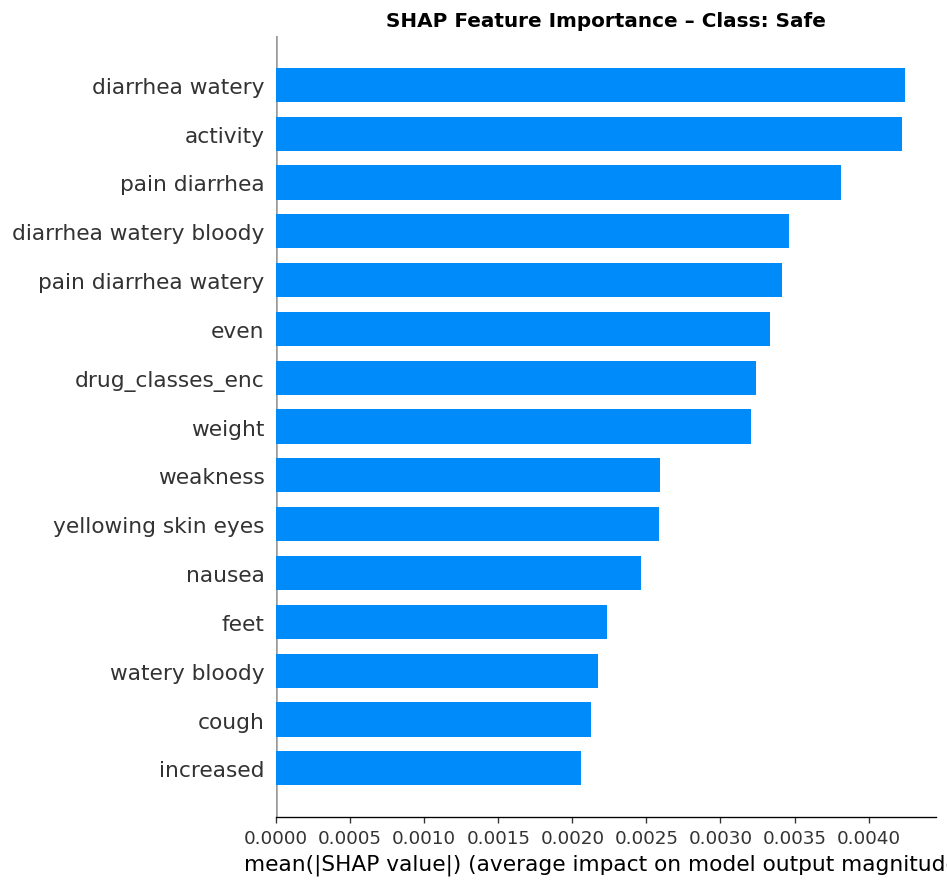

Explanation: Top 15 features influencing predictions for class Safe.


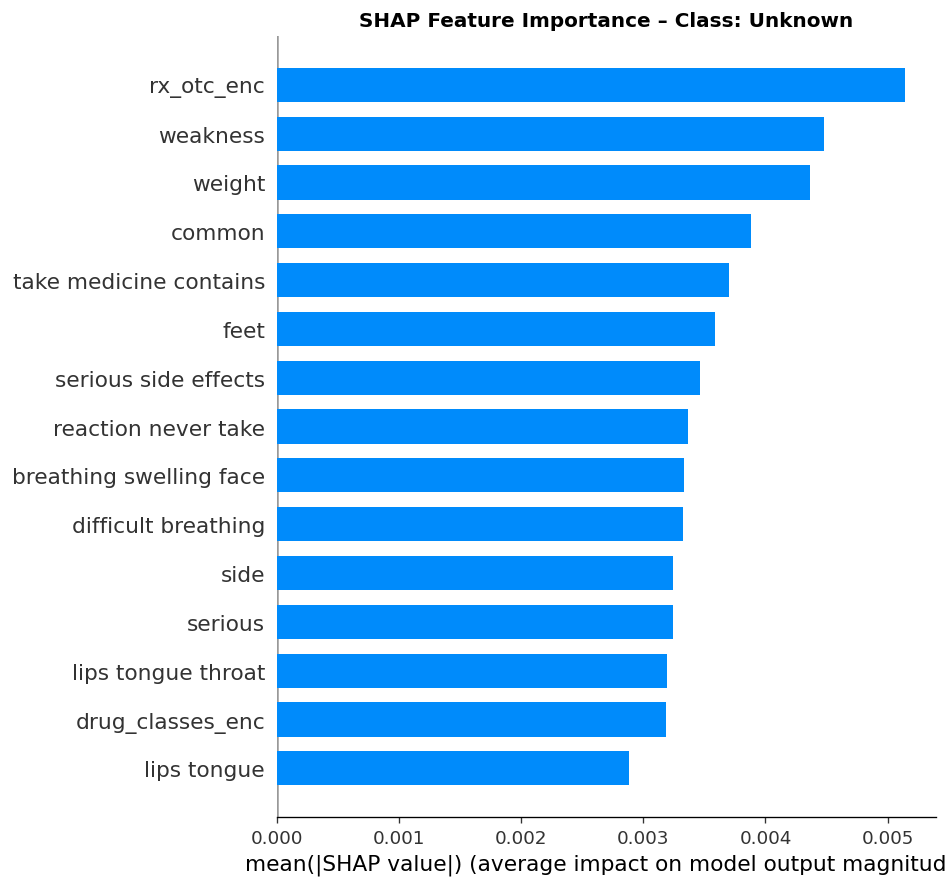

Explanation: Top 15 features influencing predictions for class Unknown.


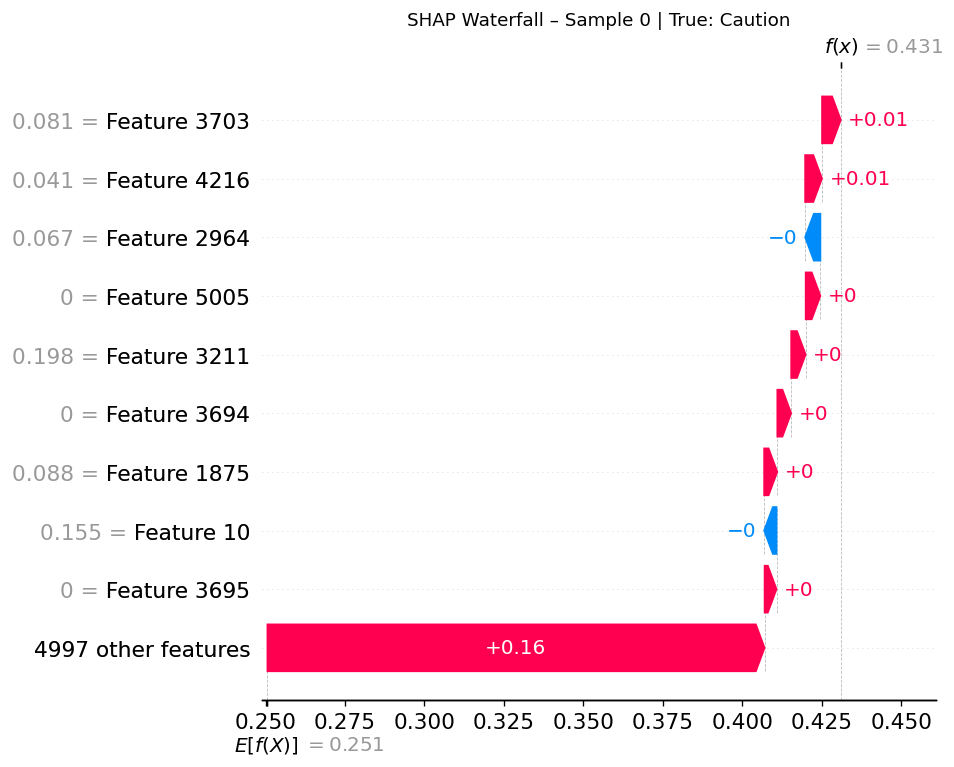

In [34]:
# SECTION 18 – SHAP EXPLAINABILITY
SHAP_SAMPLE = 150
X_test_dense = X_test.toarray()
X_shap_sample = X_test_dense[:SHAP_SAMPLE]

print(f"Computing SHAP values for {SHAP_SAMPLE} test samples")
explainer_shap = shap.TreeExplainer(rf)
shap_values = explainer_shap.shap_values(X_shap_sample)

for class_idx, class_name in enumerate(CLASS_NAMES):
    plt.figure(figsize=(6, 6))
    shap.summary_plot(
        shap_values[:, :, class_idx],
        X_shap_sample,
        feature_names=FEATURE_NAMES,
        max_display=15,
        show=False,
        plot_type="bar"
    )
    plt.title(f"SHAP Feature Importance – Class: {class_name}", fontsize=12, fontweight="bold")
    plt.tight_layout()
    plt.show()
    print(f"Explanation: Top 15 features influencing predictions for class {class_name}.")

# SHAP waterfall
shap.initjs()
sample_idx = 0
shap_exp = explainer_shap(X_shap_sample)

plt.figure(figsize=(10, 5))
target_idx = CLASS_NAMES.tolist().index("Caution") if "Caution" in CLASS_NAMES else 0
shap.plots.waterfall(shap_exp[sample_idx, :, target_idx], show=False)
plt.title(f"SHAP Waterfall – Sample {sample_idx} | True: {CLASS_NAMES[y_test[sample_idx]]}", fontsize=11)
plt.tight_layout()
plt.show()



---
### SECTION 19 – LIME EXPLAINABILITY

**LIME (Local Interpretable Model-agnostic Explanations)** is an explainable AI technique used to interpret individual predictions made by complex machine learning models.

Unlike global explanation methods, LIME focuses on explaining a single prediction by approximating the model locally with a simpler, interpretable model. This helps identify which features had the most influence on a specific decision.

In this project, LIME was applied to explain predictions from the SVM model by highlighting the key features affecting each individual medication safety classification.

**Result**

The LIME analysis produced local explanations for selected test samples, showing the most influential features for each prediction. The results indicated how specific drug attributes and side effect terms contributed to classifying a medication as Safe, Caution, or Dangerous.


Sample 0 | True: Caution | Predicted: Unknown
Top influencing features:
  virus <= 0.00                                 +0.0262
  csa_enc <= 0.28                               +0.0234
  lasting longer days <= 0.00                   -0.0193
  may include increased <= 0.00                 +0.0142
  tell doctor ongoing <= 0.00                   +0.0123
  injection given itchy <= 0.00                 +0.0091
  ill feeling fever <= 0.00                     +0.0089
  urinate heavy sweating <= 0.00                -0.0080


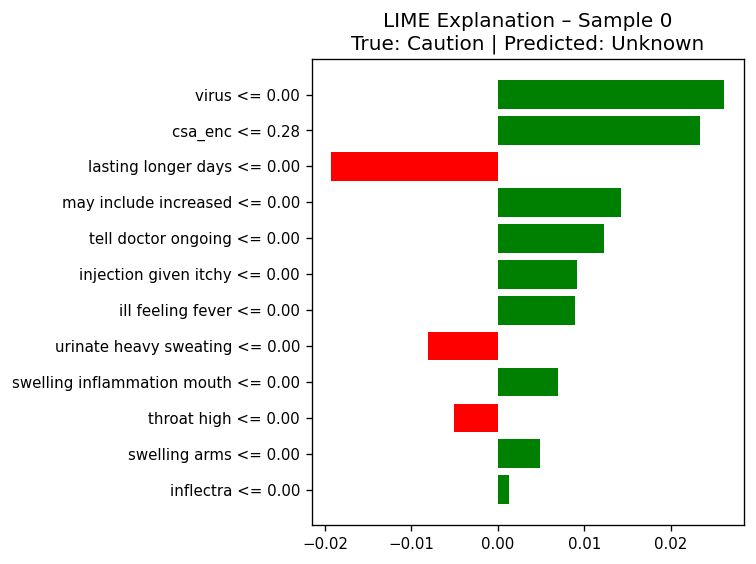


Sample 1 | True: Caution | Predicted: Caution
Top influencing features:
  arthritis <= 0.00                             +0.0997
  renflexis <= 0.00                             +0.0700
  blood material looks <= 0.00                  -0.0508
  infusion <= 0.00                              -0.0474
  csa_enc <= 0.28                               -0.0466
  ears burning <= 0.00                          +0.0168
  painful tender lymph <= 0.00                  +0.0156
  warmth one legs <= 0.00                       +0.0132


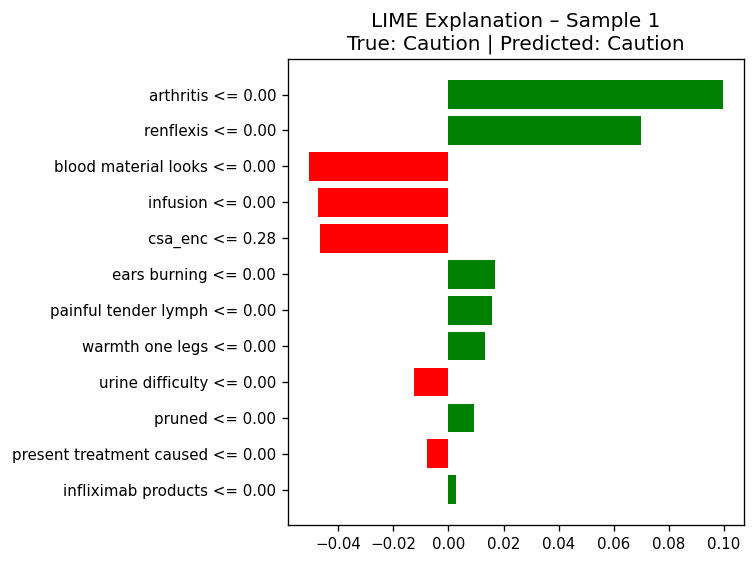


Sample 2 | True: Unknown | Predicted: Unknown
Top influencing features:
  trembling shaking hands <= 0.00               -0.0321
  avsola <= 0.00                                -0.0314
  fever chills body <= 0.00                     +0.0189
  absorb <= 0.00                                -0.0186
  feeling nervous irritable <= 0.00             +0.0161
  pain tenderness swelling <= 0.00              -0.0130
  breath coughing blood <= 0.00                 +0.0126
  doxycycline <= 0.00                           +0.0117


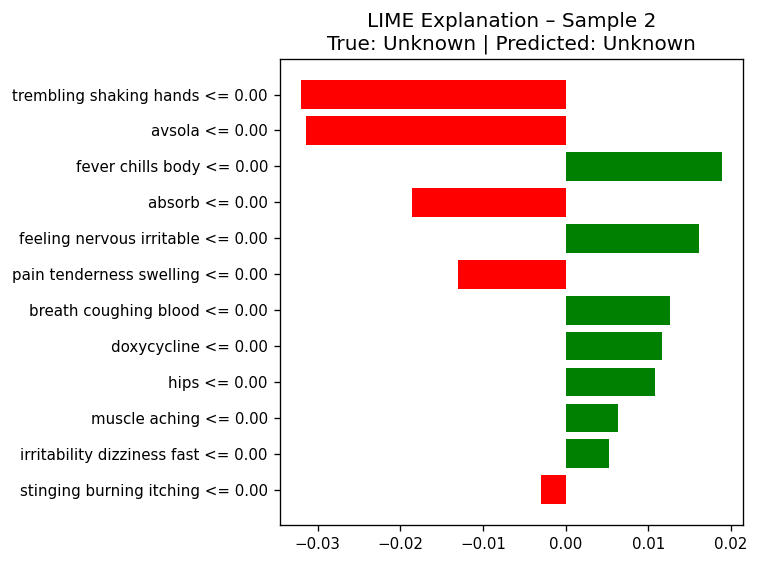

In [35]:
# SECTION 19 – LIME EXPLAINABILITY
# FIX: Use original (non-SMOTE) training data for LIME
X_train_dense = X_train.toarray()

lime_explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data=X_train_dense,
    feature_names=FEATURE_NAMES,
    class_names=CLASS_NAMES.tolist(),
    mode="classification",
    discretize_continuous=True,
    random_state=42
)

# Explain first three test samples
for sample_idx in range(3):
    pred_label_idx = best_svm.predict(X_test_dense[sample_idx].reshape(1, -1))[0]

    exp = lime_explainer.explain_instance(
        X_test_dense[sample_idx],
        best_svm.predict_proba,
        num_features=12,
        labels=[pred_label_idx]
    )
    true_label = CLASS_NAMES[y_test[sample_idx]]
    pred_label = CLASS_NAMES[pred_label_idx]

    print(f"\nSample {sample_idx} | True: {true_label} | Predicted: {pred_label}")
    print("Top influencing features:")
    for feat, weight in exp.as_list(label=pred_label_idx)[:8]:
        print(f"  {feat:<45} {weight:+.4f}")

    fig = exp.as_pyplot_figure(label=pred_label_idx)
    plt.title(f"LIME Explanation – Sample {sample_idx}\nTrue: {true_label} | Predicted: {pred_label}")
    plt.tight_layout()
    plt.show()



---
### **Section 20 – Final Results Summary**

Final results show comparison between models:

* Random Forest
* Optimized SVM
* Dummy baseline

The optimized SVM achieves the best overall performance based on cross-validation and evaluation metrics.

In [36]:
# SECTION 20 – FINAL SUMMARY

header = f"{'Model':<25} {'Accuracy':>10} {'Precision':>10} {'Recall':>10} {'F1':>10} {'ROC-AUC':>10}"
sep = "-" * len(header)
print(header)
print(sep)
print(f"{'Random Forest':<25} {rf_acc:>10.4f} {rf_prec:>10.4f} {rf_rec:>10.4f} {rf_f1:>10.4f} {rf_roc:>10.4f}")
print(f"{'SVM (optimized)':<25} {svm_acc:>10.4f} {svm_prec:>10.4f} {svm_rec:>10.4f} {svm_f1:>10.4f} {svm_roc:>10.4f}")
print(f"{'Dummy Baseline':<25} {dummy_acc:>10.4f} {'N/A':>10} {'N/A':>10} {'N/A':>10} {dummy_roc:>10.4f}")
print(sep)

print(f"\nBest SVM Parameters : {grid_search.best_params_}")
print(f"\n Pipeline completed successfully!")



Model                       Accuracy  Precision     Recall         F1    ROC-AUC
--------------------------------------------------------------------------------
Random Forest                 0.8170     0.8023     0.8084     0.8051     0.9442
SVM (optimized)               0.9372     0.9227     0.9540     0.9352     0.9935
Dummy Baseline                0.5120        N/A        N/A        N/A     0.5000
--------------------------------------------------------------------------------

Best SVM Parameters : {'C': 10, 'kernel': 'linear'}

 Pipeline completed successfully!


In [37]:
# DEBUG & VALIDATION
print("TARGET DISTRIBUTION")
print(df["safety_label"].value_counts())

print("\n\nCLASS MAPPING: ")
for i, c in enumerate(CLASS_NAMES):
    print(f"{i} -> {c}")

print("\n\nFINAL VALIDATION:")
print(f"C_VALUES: {C_VALUES}")
print(f"C scores: {c_scores}")
print(f"RF accuracy: {rf_acc}")

X_tune = X_combined_sp
y_tune = y

lr_check = LogisticRegression(max_iter=5000, class_weight="balanced", random_state=42)
lr_scores_check = cross_val_score(lr_check, X_tune, y_tune, cv=3, scoring="accuracy", n_jobs=-1)
print(f"LR CV Accuracy: {lr_scores_check.mean():.4f}")
print(f"X_combined_sp shape: {X_combined_sp.shape}")
print(f"Train class distribution: {np.bincount(y_train)}")
print(f"After SMOTE: {np.bincount(y_train_res)}")
print(f"Best Parameters: {best_params}")
print(f"Best CV Accuracy: {grid_search.best_score_:.4f}")

print("All validations completed successfully!")


TARGET DISTRIBUTION
safety_label
Caution      1382
Safe          527
Unknown       436
Dangerous     357
Name: count, dtype: int64


CLASS MAPPING: 
0 -> Caution
1 -> Dangerous
2 -> Safe
3 -> Unknown


FINAL VALIDATION:
C_VALUES: [0.1, 1, 10, 100]
C scores: [np.float64(0.6095391951329798), np.float64(0.7583244954166153), np.float64(0.8242039708965346), np.float64(0.814215069675669)]
RF accuracy: 0.8170055452865065
LR CV Accuracy: 0.5703
X_combined_sp shape: (2702, 5006)
Train class distribution: [1105  286  421  349]
After SMOTE: [1105 1105 1105  349]
Best Parameters: {'C': 10, 'kernel': 'linear'}
Best CV Accuracy: 0.8242
All validations completed successfully!


---
This marks the end of this notebook.

All stages of the project including data preprocessing, feature engineering, model training, evaluation, and explainability have been successfully completed.

### Thank you for reviewing this work.

# End of Notebook